<a href="https://colab.research.google.com/github/StrawEater/PracticasPDI3erBimestre/blob/main/Laboratorios/labo4_expositivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# Configuración

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sp_signal
from scipy.fft import fft, ifft, fft2, ifft2, fftshift, fftfreq
from skimage import data, color, transform
from skimage.draw import rectangle, line

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
plt.rcParams['image.cmap'] = 'gray'

np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(42)

# ¿Qué es una señal?

> ### Definicion
> Una señal es una lista ordenada de números con un valor por cada posicion/indice:
> - **Tiempo** → audio, temperatura, ECG, cotización del dólar
> - **Espacio** → una fila de píxeles de una imagen
> - **Dos índices a la vez** → una imagen entera $f(x, y)$

Es decir,

$$\text{señal} = \text{vector} \in \mathbb{R}^N$$


## Ejemplos de señales

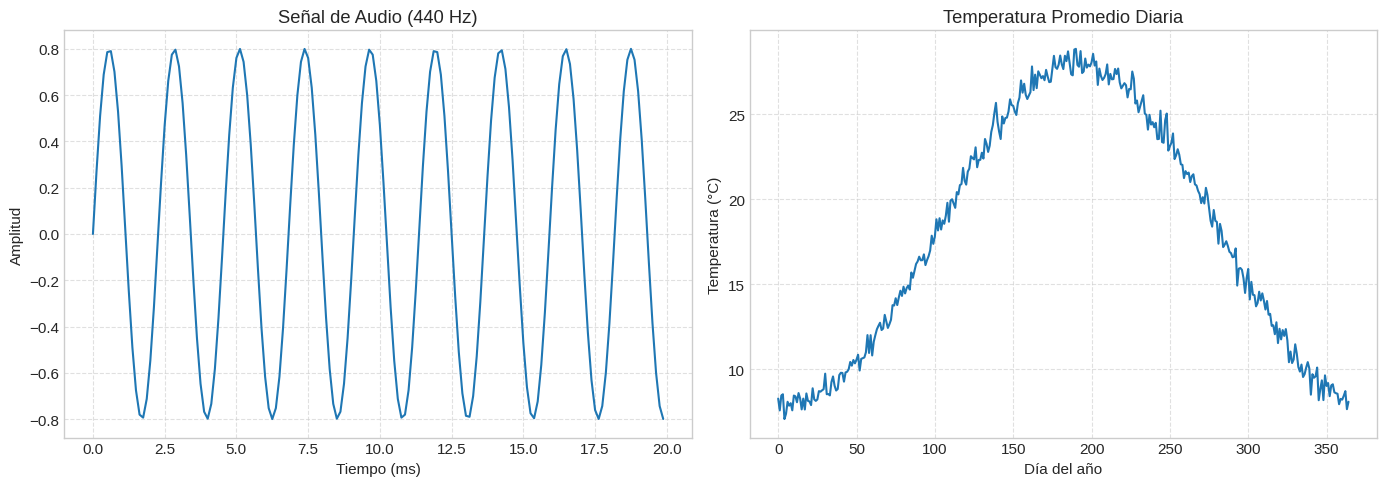

In [24]:
#Un audio a 440 Hz muestreado a 8000 muestras por segundo
frecuencia_de_muestreo = 8000
duracion = 0.02
tiempo_muestreado = np.arange(0, duracion, 1/frecuencia_de_muestreo) #10 milisegundos
audio = 0.8 * np.sin(2 * np.pi * 440 * tiempo_muestreado)

#Temperatura promedio diaria por año
dias = np.arange(365)
temperatura_promedio = 18
estacionalidad = 10*np.sin(2*np.pi*(dias-100)/365)
ruido_aleatorio = rng.normal(0, 0.5, 365)
temperatura = temperatura_promedio + estacionalidad + ruido_aleatorio

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tiempo_muestreado * 1000, audio)
axes[0].set_title("Señal de Audio (440 Hz)")
axes[0].set_xlabel("Tiempo (ms)")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(dias, temperatura)
axes[1].set_title("Temperatura Promedio Diaria")
axes[1].set_xlabel("Día del año")
axes[1].set_ylabel("Temperatura (°C)")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

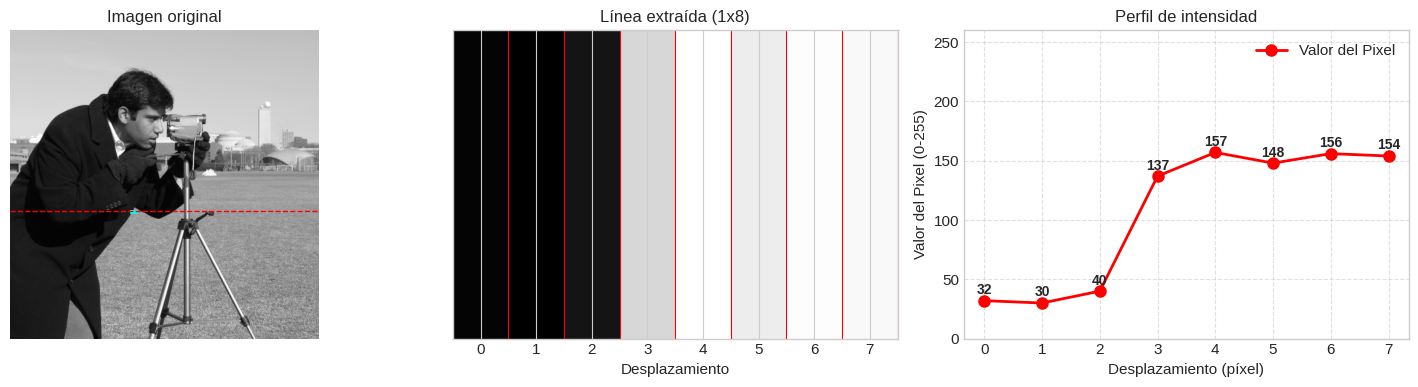

In [25]:
#Imagen de cameraman
imagen = data.camera()

fila = 300
columna_inicio = 200
ancho = 8

fila_linea = imagen[fila, columna_inicio:columna_inicio + ancho]
linea_imagen = imagen[fila:fila+1, columna_inicio:columna_inicio + ancho]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

#Imagen original
axes[0].imshow(imagen, cmap='gray')
axes[0].axhline(fila, color='red', lw=1, linestyle='--')
rect = plt.Rectangle((columna_inicio, fila - 0.5), ancho, 1, edgecolor='cyan', facecolor='none', lw=2)
axes[0].add_patch(rect)
axes[0].set_title("Imagen original", fontsize=12)
axes[0].axis('off')

#Linea de pixeles
axes[1].imshow(linea_imagen, cmap='gray', aspect='auto', interpolation='nearest')

for i in range(ancho + 1):
    axes[1].axvline(i - 0.5, color='red', lw=0.8)
axes[1].set_title("Línea extraída (1x8)", fontsize=12)
axes[1].set_xlabel("Desplazamiento")
axes[1].set_xticks(np.arange(ancho))
axes[1].set_xticklabels(np.arange(ancho))
axes[1].set_yticks([])

#Perfil de intensidad
axes[2].plot(np.arange(ancho), fila_linea, color='red', marker='o', linestyle='-', linewidth=2, markersize=8,label='Valor del Pixel')

for i, v in enumerate(fila_linea):
    axes[2].text(i, v + 3, str(v), ha='center', va='bottom', fontsize=10, weight='bold')
axes[2].set_title("Perfil de intensidad", fontsize=12)
axes[2].set_xlabel("Desplazamiento (píxel)")
axes[2].set_ylabel("Valor del Pixel (0-255)")
axes[2].set_xticks(np.arange(ancho))
axes[2].set_ylim(0, 260)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()


# ¿Que es el Seno y el Coseno?



Imagina un punto que gira sobre una circunferencia de radio 1, a velocidad constante.
En cada instante está en un ángulo $\theta$.

$$\text{posición} = (\cos\theta,\; \sin\theta)$$

- El coseno es la sombra horizontal del punto. O sea su proyeccion sobre el eje x
- El seno es la sombra vertical del punto. O sea su proyeccion sobre el eje y


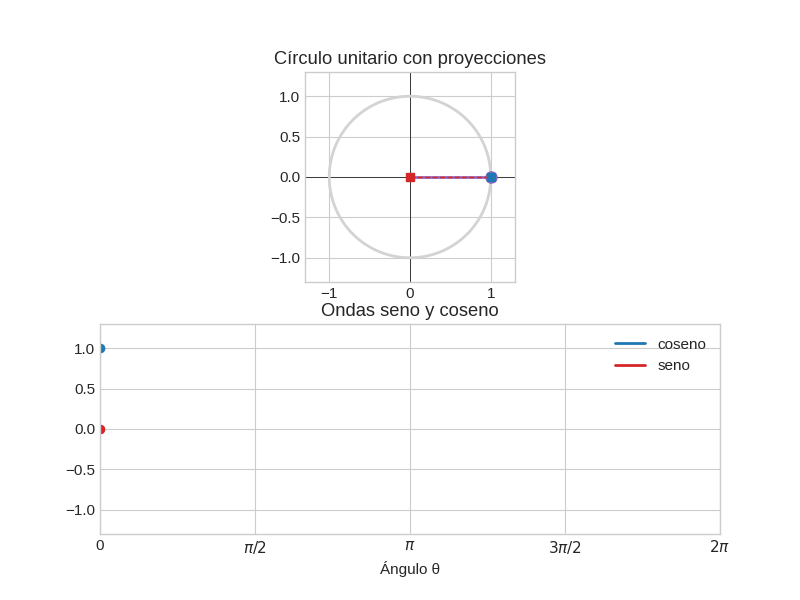

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import Image, display
import tempfile
import os

#Parametros
cantidad_fotogramas = 200
angulo_completo = np.linspace(0, 2 * np.pi, 500)
angulos_por_fotograma = np.linspace(0, 2 * np.pi, cantidad_fotogramas)


fig, (eje_circulo, eje_ondas) = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})

#Grafico de circulo unitario
eje_circulo.set_xlim(-1.3, 1.3)
eje_circulo.set_ylim(-1.3, 1.3)
eje_circulo.set_aspect('equal')
eje_circulo.axhline(0, color='k', lw=0.5)
eje_circulo.axvline(0, color='k', lw=0.5)
eje_circulo.set_title("Círculo unitario con proyecciones")

#Dibujo de la circunferencia
eje_circulo.plot(np.cos(angulo_completo), np.sin(angulo_completo), color='lightgray', lw=2)

#Cambios por fotograma
linea_radio, = eje_circulo.plot([], [], color='tab:purple', lw=2)
punto_en_circulo, = eje_circulo.plot([], [], 'o', color='tab:purple', ms=8)
sombra_vertical, = eje_circulo.plot([], [], '--', color='tab:blue', lw=1)
sombra_horizontal, = eje_circulo.plot([], [], '--', color='tab:red', lw=1)
proyeccion_x, = eje_circulo.plot([], [], 's', color='tab:blue', ms=6)
proyeccion_y, = eje_circulo.plot([], [], 's', color='tab:red', ms=6)

#Grafico de Ondas
eje_ondas.set_xlim(0, 2 * np.pi)
eje_ondas.set_ylim(-1.3, 1.3)
eje_ondas.set_xlabel("Ángulo θ")
eje_ondas.set_title("Ondas seno y coseno")

marcas_angulos = [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi]
etiquetas_angulos = ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
eje_ondas.set_xticks(marcas_angulos)
eje_ondas.set_xticklabels(etiquetas_angulos)


#Curvas a dibujar
curva_coseno, = eje_ondas.plot([], [], color='tab:blue', lw=2, label='coseno')
curva_seno, = eje_ondas.plot([], [], color='tab:red', lw=2, label='seno')
punto_coseno, = eje_ondas.plot([], [], 'o', color='tab:blue', ms=6)
punto_seno, = eje_ondas.plot([], [], 'o', color='tab:red', ms=6)

eje_ondas.legend(loc='upper right')


def iniciar():
    #Limpiar todo
    linea_radio.set_data([], [])
    punto_en_circulo.set_data([], [])
    sombra_vertical.set_data([], [])
    sombra_horizontal.set_data([], [])
    proyeccion_x.set_data([], [])
    proyeccion_y.set_data([], [])
    curva_coseno.set_data([], [])
    curva_seno.set_data([], [])
    punto_coseno.set_data([], [])
    punto_seno.set_data([], [])
    return (linea_radio, punto_en_circulo, sombra_vertical, sombra_horizontal,
            proyeccion_x, proyeccion_y,
            curva_coseno, curva_seno,punto_coseno, punto_seno)

def actualizar(fotograma):
    #Actualizar por fotograma cada uno de los graficos
    angulo_actual = angulos_por_fotograma[fotograma]
    cos_actual = np.cos(angulo_actual)
    sen_actual = np.sin(angulo_actual)

    #El circulo unitario
    linea_radio.set_data([0, cos_actual], [0, sen_actual])
    punto_en_circulo.set_data([cos_actual], [sen_actual])
    sombra_vertical.set_data([cos_actual, cos_actual], [0, sen_actual])
    sombra_horizontal.set_data([0, cos_actual], [sen_actual, sen_actual])
    proyeccion_x.set_data([cos_actual], [0])
    proyeccion_y.set_data([0], [sen_actual])

    #Las ondas seno y coseno
    cantidad_puntos = max(2, int(200 * angulo_actual / (2 * np.pi)))
    angulos_hasta_ahora = np.linspace(0, angulo_actual, cantidad_puntos)
    if len(angulos_hasta_ahora) >= 2:
        curva_coseno.set_data(angulos_hasta_ahora, np.cos(angulos_hasta_ahora))
        curva_seno.set_data(angulos_hasta_ahora, np.sin(angulos_hasta_ahora))
    else:
        curva_coseno.set_data([], [])
        curva_seno.set_data([], [])

    punto_coseno.set_data([angulo_actual], [cos_actual])
    punto_seno.set_data([angulo_actual], [sen_actual])

    return (linea_radio, punto_en_circulo, sombra_vertical, sombra_horizontal,
            proyeccion_x, proyeccion_y,
            curva_coseno, curva_seno,punto_coseno, punto_seno)

#Creamos la animacion y la guardamos temporalmente
animacion = FuncAnimation(fig, actualizar, frames=cantidad_fotogramas,init_func=iniciar, blit=True, interval=50)


with tempfile.NamedTemporaryFile(suffix='.gif', delete=False) as tmp:
    nombre_temporal = tmp.name
try:
    animacion.save(nombre_temporal, writer='pillow', fps=20, dpi=100)

    with open(nombre_temporal, 'rb') as f:
        datos_gif = f.read()
    display(Image(data=datos_gif, format='png'))

finally:
    if os.path.exists(nombre_temporal):
        os.remove(nombre_temporal)

plt.close(fig)

## Seno y coseno son la misma función corrida

Dado el gráfico de arriba podemos apreciar que el seno y coseno es la misma funcion en si solo que variando $\tfrac{\pi}{2}$

$${\;\sin(\theta) = \cos\!\left(\theta - \tfrac{\pi}{2}\right)\;}
\qquad\qquad
{\;\cos(\theta) = \sin\!\left(\theta + \tfrac{\pi}{2}\right)\;}$$

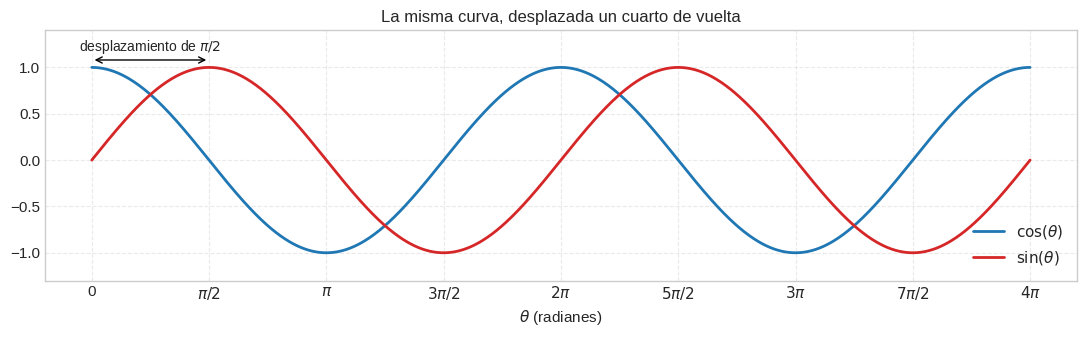

In [27]:
theta = np.linspace(0, 4 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(11, 3.5))

#Curvas
ax.plot(theta, np.cos(theta), lw=2, color='tab:blue', label=r'$\cos(\theta)$')
ax.plot(theta, np.sin(theta), lw=2, color='tab:red',  label=r'$\sin(\theta)$')

#Desfase
ax.annotate("", xy=(np.pi/2, 1.08), xytext=(0, 1.08),arrowprops=dict(arrowstyle='<->', color='k'))
ax.text(np.pi/4, 1.18, r"desplazamiento de $\pi/2$", ha='center', fontsize=10)


angulos = np.arange(0, 4*np.pi + np.pi/2, np.pi/2)
etiquetas = ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$',r'$5\pi/2$', r'$3\pi$', r'$7\pi/2$', r'$4\pi$']
ax.set_xticks(angulos)
ax.set_xticklabels(etiquetas)

ax.set_ylim(-1.3, 1.4)
ax.set_xlabel(r"$\theta$ (radianes)", fontsize=11)
ax.legend(loc='lower right')
ax.set_title("La misma curva, desplazada un cuarto de vuelta", fontsize=12)

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Los tres únicos parámetros de una onda

Una onda sinusoidal cualquiera se escribe:

$$s(t) = \underbrace{A}_{\text{amplitud}} \cdot \cos\Big( 2\pi \underbrace{f}_{\text{frecuencia}} t + \underbrace{\varphi}_{\text{fase}} \Big)$$


Donde:

*   **$A$** → **amplitud**: qué tan alta o baja llega la onda (su "tamaño").
*   **$f$** → **frecuencia**: cuántas oscilaciones completas da en 1 segundo. Se mide en **Hz** (vueltas por segundo).
*   **$\varphi$** → **fase**: dónde empieza la onda en $t = 0$ (un corrimiento horizontal)

**Y donde muchas veces simplificamos $2\pi f$ a $\omega$**

Donde **$\omega$** se llama frecuencia angular y se mide en (rad/s) (Angulo corrido por segundo)

$$ s(t) = A \cdot \cos(\omega t + \varphi) $$

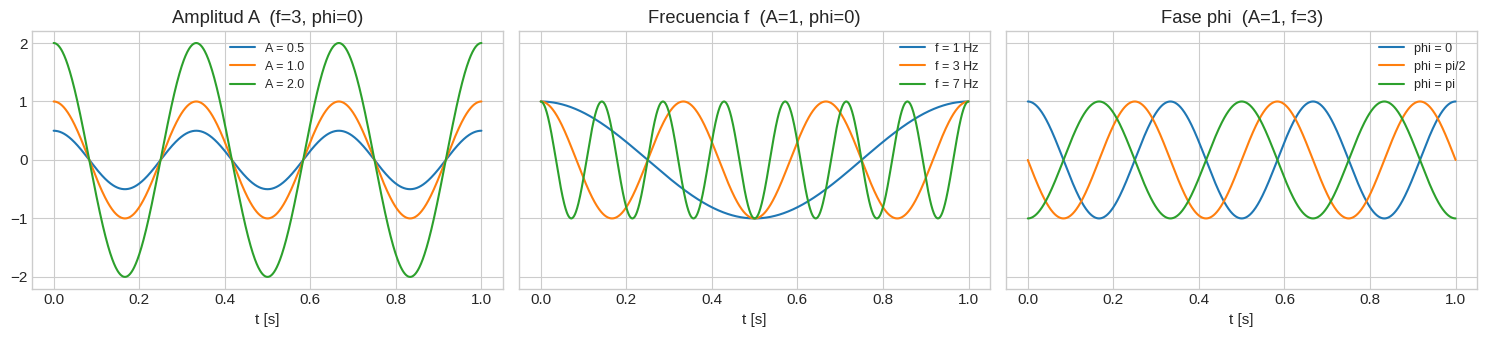

In [28]:
t = np.linspace(0, 1, 1000)

def onda(A, f, phi, t=t):
    return A * np.cos(2*np.pi*f*t + phi)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5), sharey=True)

for A in [0.5, 1.0, 2.0]:
    axes[0].plot(t, onda(A, 3, 0), label=f"A = {A}")
axes[0].set_title("Amplitud A  (f=3, phi=0)")

for f in [1, 3, 7]:
    axes[1].plot(t, onda(1, f, 0), label=f"f = {f} Hz")
axes[1].set_title("Frecuencia f  (A=1, phi=0)")

for phi, nombre in [(0, "0"), (np.pi/2, "pi/2"), (np.pi, "pi")]:
    axes[2].plot(t, onda(1, 3, phi), label=f"phi = {nombre}")
axes[2].set_title("Fase phi  (A=1, f=3)")

for ax in axes:
    ax.set_xlabel("t [s]"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## El problema de la fase (y por qué existen $a_n$ y $b_n$)

Sumar dos ondas con misma frecuencia pero diferente angulo de fase es horrible. Hay que hacer trigonometría para calcular cuanto da la onda resultante.

Para simplificamos pro la identidad de la suma de los angulos

$$\cos(\alpha + \beta) = \cos\alpha\cos\beta - \sin\alpha\sin\beta$$

$$A\cos(2\pi f t + \varphi)
= \underbrace{\big(A\cos\varphi\big)}_{\textstyle a}\cos(2\pi f t)
\; \underbrace{-\big(A\sin\varphi\big)}_{\textstyle b}\sin(2\pi f t)$$

$$\boxed{\;A\cos(2\pi f t + \varphi) \;=\; a\,\cos(2\pi f t) \;+\; b\,\sin(2\pi f t)\;}$$



<details>
<summary >
    Ver el desarrollo matemático completo (Antes vs Después)
</summary>

## ANTES: Sumar ondas con fases

Tenemos dos ondas de la **misma frecuencia** ($\omega = 2\pi f$), pero con diferentes amplitudes y fases:

# $$ s_1(t) = A_1 \cos(\omega t + \varphi_1) $$
$$ s_2(t) = A_2 \cos(\omega t + \varphi_2) $$

Queremos sumarlas para obtener una única onda resultante:

$$ s(t) = s_1(t) + s_2(t) = A \cos(\omega t + \varphi) $$

Desarrollamos cada coseno usando la identidad de la suma de ángulos:

$$ A_1 \cos(\omega t + \varphi_1) = A_1\cos(\omega t)\cos\varphi_1 - A_1\sin(\omega t)\sin\varphi_1 $$
$$ A_2 \cos(\omega t + \varphi_2) = A_2\cos(\omega t)\cos\varphi_2 - A_2\sin(\omega t)\sin\varphi_2 $$

Sumamos y agrupamos términos:

$$ s(t) = \underbrace{(A_1\cos\varphi_1 + A_2\cos\varphi_2)}_{A} \cos(\omega t)
- \underbrace{(A_1\sin\varphi_1 + A_2\sin\varphi_2)}_{B} \sin(\omega t) $$

Luego, para encontrar la amplitud y fase de la resultante hay que aplicar Pitágoras y arco tangente:

$$ \boxed{ A = \sqrt{A^2 + B^2} } \quad , \quad \boxed{ \varphi = \arctan\left(\frac{A}{B}\right) } $$

Es decir, explícitamente:

$$ \boxed{ A = \sqrt{(A_1\cos\varphi_1 + A_2\cos\varphi_2)^2 + (A_1\sin\varphi_1 + A_2\sin\varphi_2)^2} } $$

##DESPUÉS: Sumar ondas con coeficientes (a,b)

Ahora usamos la misma identidad pero para reescribir cada onda antes de sumar.

Definimos para cada onda sus coordenadas cartesianas:

$$ a_i = A_i \cos\varphi_i, \qquad b_i = A_i \sin\varphi_i $$

Entonces CADA onda se reescribe como:

$$ s_i(t) = A_i \cos(\omega t + \varphi_i) = a_i \cos(\omega t) + b_i \sin(\omega t) $$

Luego, ¡Sumar ondas es ahora sumar números sueltos!

Para la suma de las dos ondas:

$$ s(t) = (a_1 + a_2) \cos(\omega t) + (b_1 + b_2) \sin(\omega t) $$

Definimos los coeficientes totales:

$$ \boxed{ a = a_1 + a_2 } \quad  \quad \boxed{ b = b_1 + b_2 } $$


$$ \boxed{ A = \sqrt{a^2 + b^2} } \quad \quad \boxed{ \varphi = \arctan\left(\frac{b}{a}\right) } $$


                        a           b       |     A        phi
  onda 1           +0.7071   +0.7071   |  1.0000   -0.250 pi
  onda 2           +0.5000   -0.8660   |  1.0000   +0.333 pi
  SUMA             +1.2071   -0.1589   |  1.2175   +0.042 pi

  a1 + a2 = a_total ?  1.2071 == 1.2071   -> SI, las componentes se suman
  A1 + A2 = A_total ?  2.0000 != 1.2175   -> NO, las amplitudes NO se suman

Coincide la suma por componentes con la suma real? True


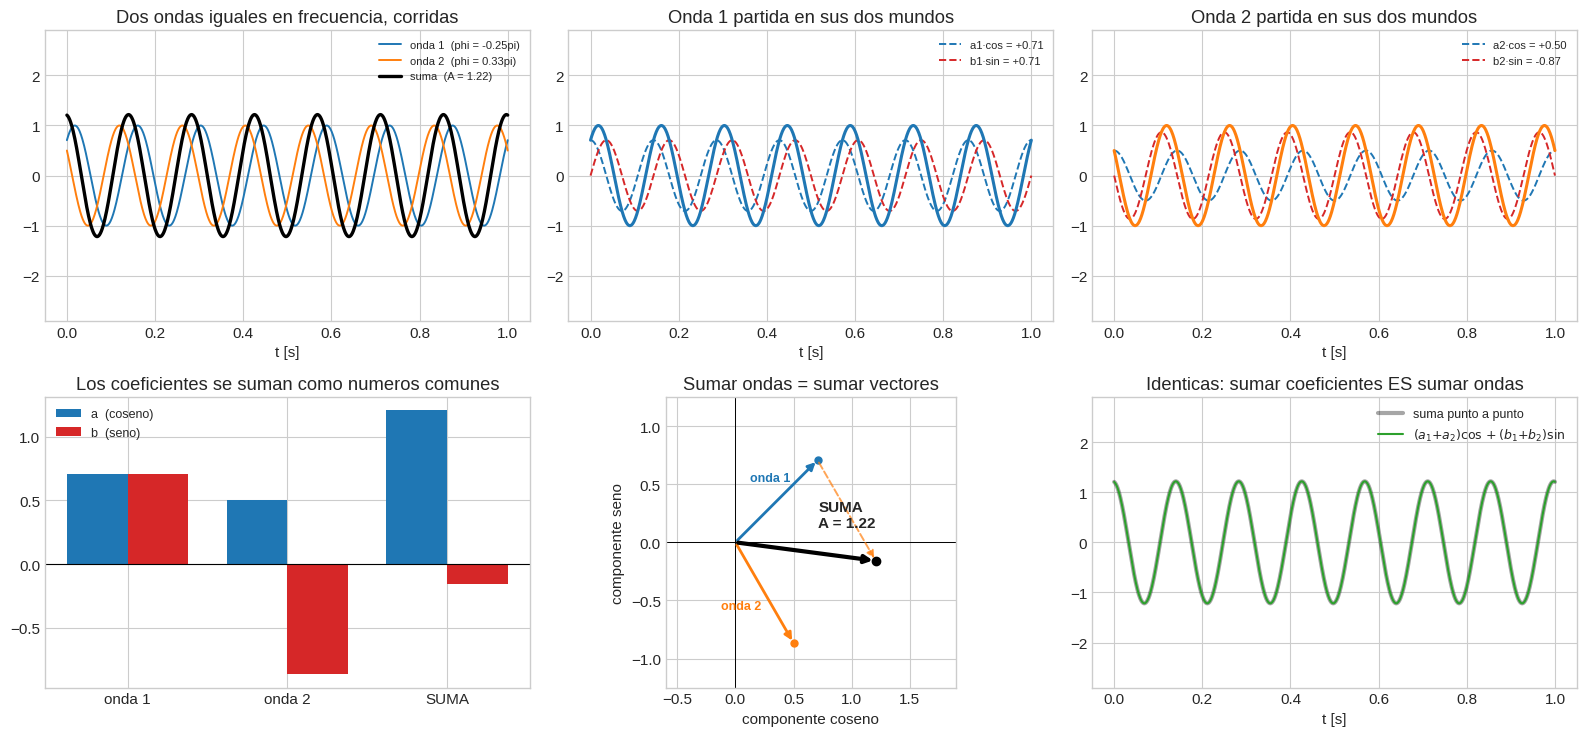

In [29]:
# ---- Dos ondas de igual frecuencia y distinta fase ----
A1, phi1 = 1.0, -np.pi/4
A2, phi2 = 1.0,  np.pi/3

onda1 = A1 * np.cos(2*np.pi*f*t + phi1)
onda2 = A2 * np.cos(2*np.pi*f*t + phi2)
suma_directa = onda1 + onda2                    # la verdad, punto a punto

# --- camino lindo: paso cada una a (a, b) y sumo componente a componente ---
a1, b1 = A1*np.cos(phi1), -A1*np.sin(phi1)
a2, b2 = A2*np.cos(phi2), -A2*np.sin(phi2)
a_tot, b_tot = a1 + a2, b1 + b2

suma_por_componentes = a_tot*np.cos(2*np.pi*f*t) + b_tot*np.sin(2*np.pi*f*t)

# y si quiero, vuelvo a polares al final
A_tot   = np.hypot(a_tot, b_tot)
phi_tot = np.arctan2(-b_tot, a_tot)

print(f"                        a           b       |     A        phi")
print(f"  onda 1          {a1:+8.4f}  {b1:+8.4f}   |  {A1:6.4f}   {phi1/np.pi:+.3f} pi")
print(f"  onda 2          {a2:+8.4f}  {b2:+8.4f}   |  {A2:6.4f}   {phi2/np.pi:+.3f} pi")
print(f"  SUMA            {a_tot:+8.4f}  {b_tot:+8.4f}   |  {A_tot:6.4f}   {phi_tot/np.pi:+.3f} pi")
print()
print(f"  a1 + a2 = a_total ?  {a1+a2:.4f} == {a_tot:.4f}   -> SI, las componentes se suman")
print(f"  A1 + A2 = A_total ?  {A1+A2:.4f} != {A_tot:.4f}   -> NO, las amplitudes NO se suman")
print()
print("Coincide la suma por componentes con la suma real?",
      np.allclose(suma_directa, suma_por_componentes))

fig, axes = plt.subplots(2, 3, figsize=(16, 7.5))

# (0,0) las dos ondas y su suma
ax = axes[0, 0]
ax.plot(t, onda1, color='tab:blue',   lw=1.4, label=f'onda 1  (phi = {phi1/np.pi:.2f}pi)')
ax.plot(t, onda2, color='tab:orange', lw=1.4, label=f'onda 2  (phi = {phi2/np.pi:.2f}pi)')
ax.plot(t, suma_directa, 'k', lw=2.4, label=f'suma  (A = {A_tot:.2f})')
ax.set_title("Dos ondas iguales en frecuencia, corridas"); ax.set_xlabel("t [s]")
ax.legend(fontsize=8, loc='upper right'); ax.set_ylim(-2.9, 2.9)

# (0,1) descomposicion de onda 1
ax = axes[0, 1]
ax.plot(t, a1*np.cos(2*np.pi*f*t), '--', color='tab:blue', lw=1.4, label=f'a1·cos = {a1:+.2f}')
ax.plot(t, b1*np.sin(2*np.pi*f*t), '--', color='tab:red',  lw=1.4, label=f'b1·sin = {b1:+.2f}')
ax.plot(t, onda1, color='tab:blue', lw=2.2)
ax.set_title("Onda 1 partida en sus dos mundos"); ax.set_xlabel("t [s]")
ax.legend(fontsize=8, loc='upper right'); ax.set_ylim(-2.9, 2.9)

# (0,2) descomposicion de onda 2
ax = axes[0, 2]
ax.plot(t, a2*np.cos(2*np.pi*f*t), '--', color='tab:blue', lw=1.4, label=f'a2·cos = {a2:+.2f}')
ax.plot(t, b2*np.sin(2*np.pi*f*t), '--', color='tab:red',  lw=1.4, label=f'b2·sin = {b2:+.2f}')
ax.plot(t, onda2, color='tab:orange', lw=2.2)
ax.set_title("Onda 2 partida en sus dos mundos"); ax.set_xlabel("t [s]")
ax.legend(fontsize=8, loc='upper right'); ax.set_ylim(-2.9, 2.9)

# (1,0) barras de coeficientes
ax = axes[1, 0]
pos = np.arange(3)
ax.bar(pos-0.19, [a1, a2, a_tot], 0.38, color='tab:blue', label='a  (coseno)')
ax.bar(pos+0.19, [b1, b2, b_tot], 0.38, color='tab:red',  label='b  (seno)')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(pos); ax.set_xticklabels(['onda 1', 'onda 2', 'SUMA'])
ax.set_title("Los coeficientes se suman como numeros comunes")
ax.legend(fontsize=9)

# (1,1) suma vectorial en el plano (a, b)
ax = axes[1, 1]
for (aa, bb, col, nom, dx, dy) in [(a1, b1, 'tab:blue',   'onda 1', -0.30,  0.10),
                                   (a2, b2, 'tab:orange', 'onda 2', -0.42, -0.05)]:
    ax.annotate("", xy=(aa, bb), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color=col, lw=2))
    ax.plot(aa, bb, 'o', color=col, ms=5)
    ax.text(aa*0.6 + dx, bb*0.6 + dy, nom, color=col, fontsize=9, fontweight='bold')
# el paralelogramo: onda2 apoyada en la punta de onda1
ax.annotate("", xy=(a_tot, b_tot), xytext=(a1, b1),
            arrowprops=dict(arrowstyle='-|>', color='tab:orange', lw=1.4, ls='--', alpha=0.7))
ax.annotate("", xy=(a_tot, b_tot), xytext=(0, 0),
            arrowprops=dict(arrowstyle='-|>', color='k', lw=3))
ax.plot(a_tot, b_tot, 'ko', ms=6)
ax.text(a_tot*0.55 + 0.05, b_tot*0.55 + 0.22, f'SUMA\nA = {A_tot:.2f}', fontweight='bold')
ax.axhline(0, color='k', lw=0.7); ax.axvline(0, color='k', lw=0.7)
ax.set_xlim(-0.6, 1.9); ax.set_ylim(-1.25, 1.25); ax.set_aspect('equal')
ax.set_xlabel("componente coseno"); ax.set_ylabel("componente seno")
ax.set_title("Sumar ondas = sumar vectores")

# (1,2) verificacion
ax = axes[1, 2]
ax.plot(t, suma_directa, color='k', lw=3, alpha=0.35, label='suma punto a punto')
ax.plot(t, suma_por_componentes, color='tab:green', lw=1.5,
        label=r'$(a_1{+}a_2)\cos + (b_1{+}b_2)\sin$')
ax.set_title("Identicas: sumar coeficientes ES sumar ondas"); ax.set_xlabel("t [s]")
ax.legend(fontsize=9, loc='upper right'); ax.set_ylim(-2.9, 2.9)

plt.tight_layout(); plt.show()


# 2. SERIE DE FOURIER = Sumar ondas

> ### Serie de Fourier
> **Cualquier señal razonable se puede escribir como una SUMA de ondas simples.**


$$f(t) \;=\; \sum_n \Big( a_n \cos(2\pi n f_0 t) + b_n \sin(2\pi n f_0 t) \Big)$$


Hay una **combinación lineal**

Las frecuencias $n f_0$ (múltiplos enteros de una frecuencia base $f_0$) se llaman **armónicos**

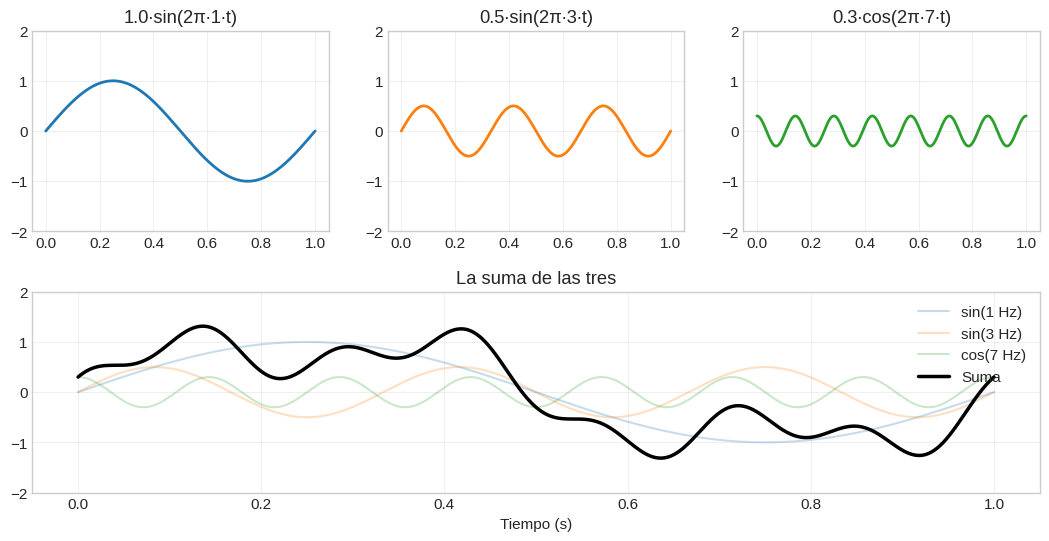

In [30]:
t = np.linspace(0, 1, 1000)

o1 = 1.0 * np.sin(2 * np.pi * 1 * t)
o2 = 0.5 * np.sin(2 * np.pi * 3 * t)
o3 = 0.3 * np.cos(2 * np.pi * 7 * t)
suma = o1 + o2 + o3

fig = plt.figure(figsize=(13, 6))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1], hspace=0.3)

#Graficos individuales
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(t, o1, color='tab:blue', lw=2)
ax1.set_title("1.0·sin(2π·1·t)")
ax1.set_ylim(-2, 2)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(t, o2, color='tab:orange', lw=2)
ax2.set_title("0.5·sin(2π·3·t)")
ax2.set_ylim(-2, 2)
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t, o3, color='tab:green', lw=2)
ax3.set_title("0.3·cos(2π·7·t)")
ax3.set_ylim(-2, 2)
ax3.grid(True, alpha=0.3)

#Grafico de la suma resultante
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(t, o1, color='tab:blue', alpha=0.25, label='sin(1 Hz)')
ax4.plot(t, o2, color='tab:orange', alpha=0.25, label='sin(3 Hz)')
ax4.plot(t, o3, color='tab:green', alpha=0.25, label='cos(7 Hz)')
ax4.plot(t, suma, color='k', lw=2.5, label='Suma')
ax4.set_title("La suma de las tres")
ax4.set_ylim(-2, 2)
ax4.set_xlabel("Tiempo (s)")
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper right')

plt.show()

## Caso de ejemplo

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Dominio de -π a π
x = np.linspace(-np.pi, np.pi, 2000)

# Onda cuadrada ideal (referencia)
cuadrada = np.where(x >= 0, 1.0, -1.0)

# Función que reconstruye la cuadrada sumando los primeros K armónicos impares
def reconstruir_cuadrada(K):
    s = np.zeros_like(x)
    for n in range(1, K+1, 2):
        s += (4.0 / (n * np.pi)) * np.sin(n * x)
    return s

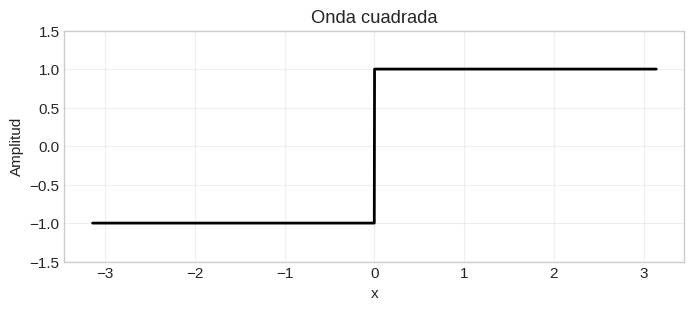

In [32]:
plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k-', lw=2)
plt.title("Onda cuadrada")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

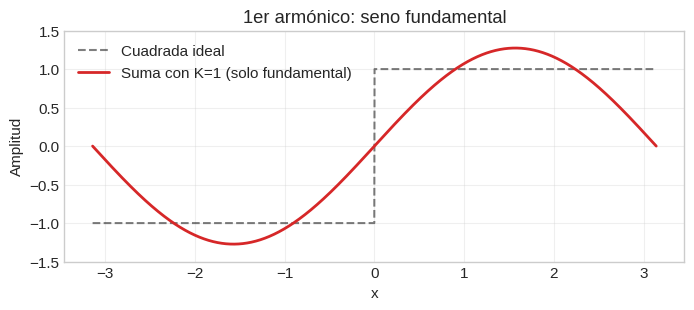

In [33]:
K = 1
s1 = reconstruir_cuadrada(K)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.5, label='Cuadrada ideal')
plt.plot(x, s1, 'tab:red', lw=2, label=f'Suma con K={K} (solo fundamental)')
plt.title("1er armónico: seno fundamental")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

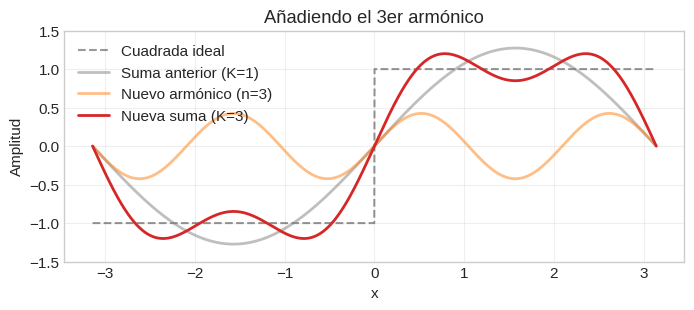

In [34]:
K_prev = 1
K_new = 3
s_prev = reconstruir_cuadrada(K_prev)
s_new = reconstruir_cuadrada(K_new)

# El nuevo armónico es la diferencia
armonico_nuevo = (4.0/(3*np.pi)) * np.sin(3*x)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.4, label='Cuadrada ideal')
plt.plot(x, s_prev, 'gray', lw=2, alpha=0.5, label=f'Suma anterior (K={K_prev})')
plt.plot(x, armonico_nuevo, 'tab:orange', lw=2, alpha=0.5, label='Nuevo armónico (n=3)')
plt.plot(x, s_new, 'tab:red', lw=2, label=f'Nueva suma (K={K_new})')
plt.title("Añadiendo el 3er armónico")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

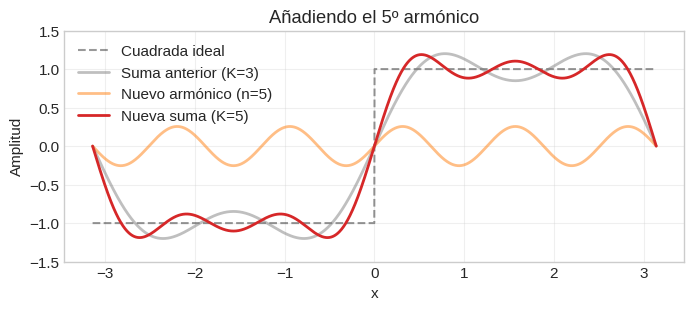

In [35]:
K_prev = 3
K_new = 5
s_prev = reconstruir_cuadrada(K_prev)
s_new = reconstruir_cuadrada(K_new)

armonico_nuevo = (4.0/(5*np.pi)) * np.sin(5*x)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.4, label='Cuadrada ideal')
plt.plot(x, s_prev, 'gray', lw=2, alpha=0.5, label=f'Suma anterior (K={K_prev})')
plt.plot(x, armonico_nuevo, 'tab:orange', lw=2, alpha=0.5, label='Nuevo armónico (n=5)')
plt.plot(x, s_new, 'tab:red', lw=2, label=f'Nueva suma (K={K_new})')
plt.title("Añadiendo el 5º armónico")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

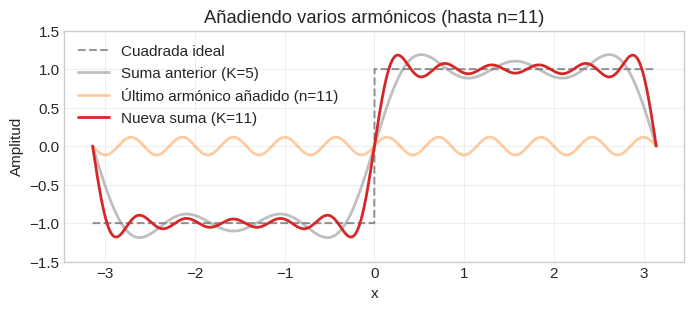

In [36]:
K_prev = 5
K_new = 11
s_prev = reconstruir_cuadrada(K_prev)
s_new = reconstruir_cuadrada(K_new)

armonico_nuevo = (4.0/(11*np.pi)) * np.sin(11*x)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.4, label='Cuadrada ideal')
plt.plot(x, s_prev, 'gray', lw=2, alpha=0.5, label=f'Suma anterior (K={K_prev})')
plt.plot(x, armonico_nuevo, 'tab:orange', lw=2, alpha=0.4, label='Último armónico añadido (n=11)')
plt.plot(x, s_new, 'tab:red', lw=2, label=f'Nueva suma (K={K_new})')
plt.title("Añadiendo varios armónicos (hasta n=11)")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

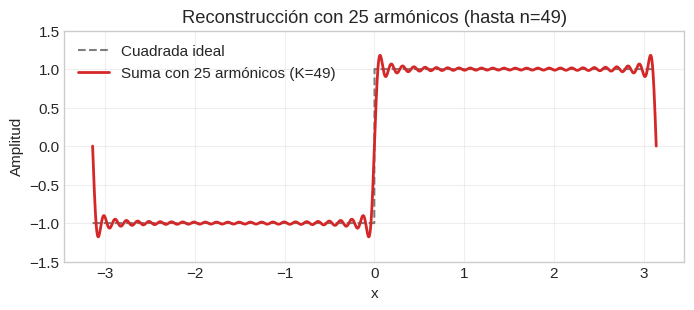

In [37]:
K = 49
s = reconstruir_cuadrada(K)

plt.figure(figsize=(8, 3))
plt.plot(x, cuadrada, 'k--', lw=1.5, alpha=0.5, label='Cuadrada ideal')
plt.plot(x, s, 'tab:red', lw=2, label=f'Suma con {len(range(1,K+1,2))} armónicos (K={K})')
plt.title("Reconstrucción con 25 armónicos (hasta n=49)")
plt.xlabel("x")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-1.5, 1.5)
plt.show()

# El producto interno: el medidor de parecido



> - La operación que mide **proyección, similitud, ángulo y solapamiento** es el
>   **producto interno** (o escalar), y devuelve **un número**:
>   $$\langle \vec{u}, \vec{v} \rangle = \sum_{i=1}^n u_i v_i$$
>
> Es **este** el que generalizamos a funciones y el que está en el corazón de Fourier.

### ¿Qué hace el producto interno geométricamente?
1. **Mide parecido / alineación:**
   - Si dos vectores apuntan en la misma dirección, su producto interno es positivo y grande.
   - Si son **perpendiculares (ortogonales)**, $\langle \vec{u}, \vec{v} \rangle = 0$.
2. **Extrae coordenadas (Proyección):**
   Si tenemos una base ortonormal canónica en $\mathbb{R}^3$, por ejemplo $\hat{e}_1 = (1, 0, 0)$, y un vector cualquiera $v = (v_1, v_2, v_3)$:
   $$c_1 = \vec{v} \cdot \hat{e}_1 = v_1 \cdot 1 + _2 \cdot 0 + v_3 \cdot 0 = v_1$$

**El producto interno actúa como un "sensor"**: cuando hacés el producto interno de $\vec{v}$ contra un vector de la base $\hat{e}_i$, el producto anula todas las demás componentes y **pesca únicamente la coordenada en esa dirección**.

Tenemos el vector $\mathbf{v} = (3, 2)$ y la base canónica  
$\hat{e}_1 = (1, 0)$, $\hat{e}_2 = (0, 1)$.

Queremos expresar $\mathbf{v}$ como **combinación lineal** de la base:

$$ \mathbf{v} = c_1 \hat{e}_1 + c_2 \hat{e}_2 $$

De forma general, si tenemos una base ortonormal $\{\hat{e}_1, \hat{e}_2, \dots, \hat{e}_n\}$, la expresión se escribe como una **sumatoria**:

$$ \mathbf{v} = \sum_{i=1}^{n} c_i \hat{e}_i, \qquad c_i = \langle \mathbf{v}, \hat{e}_i \rangle $$

En nuestro caso, $n=2$:

$$ \mathbf{v} = \sum_{i=1}^{2} c_i \hat{e}_i = c_1 \hat{e}_1 + c_2 \hat{e}_2 $$

Los coeficientes se obtienen mediante el **producto interno** (producto punto):

$$ c_1 = \langle \mathbf{v}, \hat{e}_1 \rangle, \qquad c_2 = \langle \mathbf{v}, \hat{e}_2 \rangle $$

- Para $c_1$:

$$ c_1 = \langle (3, 2), (1, 0) \rangle
      = 3 \cdot 1 + 2 \cdot 0
      = 3 + 0
      = 3 $$

- Para $c_2$:

$$ c_2 = \langle (3, 2), (0, 1) \rangle
      = 3 \cdot 0 + 2 \cdot 1
      = 0 + 2
      = 2 $$

**Reconstrucción:**

$$ c_1 \hat{e}_1 + c_2 \hat{e}_2
   = 3 \cdot (1, 0) + 2 \cdot (0, 1)
   = (3, 0) + (0, 2)
   = (3, 2) = \mathbf{v} $$



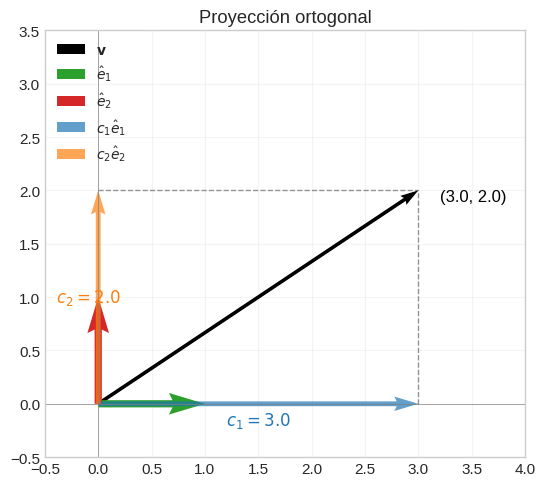

In [38]:
# @title
v = np.array([3.0, 2.0])
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

c1 = np.dot(v, e1)
c2 = np.dot(v, e2)


fig, ax = plt.subplots(figsize=(6, 5))

ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,color='k', linewidth=2, label=r'$\mathbf{v}$')

ax.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1,color='tab:green', width=0.015, label=r'$\hat{e}_1$')
ax.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1,color='tab:red', width=0.015, label=r'$\hat{e}_2$')

# Proyecciones
proy_x = c1 * e1
proy_y = c2 * e2
ax.quiver(0, 0, proy_x[0], proy_x[1], angles='xy', scale_units='xy', scale=1,color='tab:blue', alpha=0.7, width=0.01, label=r'$c_1 \hat{e}_1$')
ax.quiver(0, 0, proy_y[0], proy_y[1], angles='xy', scale_units='xy', scale=1, color='tab:orange', alpha=0.7, width=0.01, label=r'$c_2 \hat{e}_2$')

# Líneas auxiliares
ax.plot([v[0], v[0]], [0, v[1]], 'k--', alpha=0.4, lw=1)
ax.plot([0, v[0]], [v[1], v[1]], 'k--', alpha=0.4, lw=1)

# Anotaciones
ax.text(v[0]/2, -0.2, f'$c_1 = {c1}$', ha='center', fontsize=12, color='tab:blue')
ax.text(-0.4, v[1]/2, f'$c_2 = {c2}$', va='center', fontsize=12, color='tab:ORANGE')
ax.text(v[0]+0.2, v[1]-0.1, f'({v[0]}, {v[1]})', fontsize=12, color='k')

# Ajustes del gráfico
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 3.5)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')
ax.set_title("Proyección ortogonal")
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## El Espacio de Funciones: Vectores de Infinitas Dimensiones

### ¿Qué tiene que ver una función con un vector? ¡Son lo mismo!
Pensá en cómo se guarda una señal en la computadora, puede ser un sonido, un registro de la temperatura a lo largo del tiempo, etc:
- Se hace un muestreo de la función $f(t)$ cada 1 segundo por ejemplo: tenés una lista de números $[f(1), f(2), \dots, f(n)]$. ¡Esto es un vector en $\mathbb{R}^N$!
- Muestreo cada 1 milisegundo: el vector tiene 1000 veces más componentes.
- Si se hiciera un espaciado infinitesimal ($dx \to 0$), la lista ya no tendría índices discretos $i \in \{1, 2, \dots, n\}$, sino un índice continuo $x$.

Una función continua $f(x)$ **es simplemente un vector con infinitas componentes continuas**.

### ¿Cumple los axiomas de espacio vectorial?
Absolutamente sí:
1. **Suma:** $(f + g)(x) = f(x) + g(x)$ (sumás componente a componente).
2. **Multiplicación por escalar:** $(c \cdot f)(x) = c \cdot f(x)$.
3. Cumple distributividad, asociatividad, elemento neutro (la función nula $0$), etc.

### ¿Cómo se calcula el producto interno en este espacio?
En $\mathbb{R}^N$:
$$\langle u, v \rangle = \sum_{i=1}^N u_i v_i$$

Al pasar a un índice continuo $x$, la sumatoria $\sum$ se convierte de forma natural en una **integral** $\int$:
$$\langle f, g \rangle = \int_a^b f(x) g(x) dx$$

¡Es exactamente la misma idea! Multiplicás las funciones punto a punto y sumás todas las componentes. Si $\langle f, g \rangle = 0$, decimos que las dos funciones son **ortogonales**.



# Correlación y convolución: el producto interno **deslizante**



El producto interno $\langle f, g\rangle$ compara dos señales **cuando están perfectamente superpuestas**.
Pero en la vida real:

> Tengo una señal $f$ y busco un patrón $g$, **pero no sé dónde aparece**.

La solución es obvia: **deslizo** el patrón por toda la señal y en **cada posición**
hago un producto interno. Me queda una **nueva señal**: un número por cada desplazamiento.

$$(f \star g)[t] \;=\; ⟨f(\tau),g(\tau+t) ⟩ \;=\;\sum_{\tau} f[\tau]\; g[\tau + t]$$

o, en versión continua, exactamente lo mismo con el otro símbolo de suma:

$$(f \star g)(t) \;=\; \int_{-\infty}^{\infty} f(\tau)\, g(\tau + t)\, d\tau \qquad \text{(Correlación Cruzada)}$$

> **La Correlacion es un "escáner de producto interno":**
> En cada instante $t$, la correlacion calcula el producto interno entre $f$ y $g$. Si en algún instante las dos formas coinciden, el producto interno produce un pico máximo.

Y si además invertís el tiempo de la segunda función:
$$(f * g)(t) = \int_{-\infty}^\infty f(\tau) g(t - \tau) d\tau \quad \text{(Convolución)}$$
> La **Convolución** aplica la misma idea de la Correlación pero con la versión desplazada e invertida de $g$.

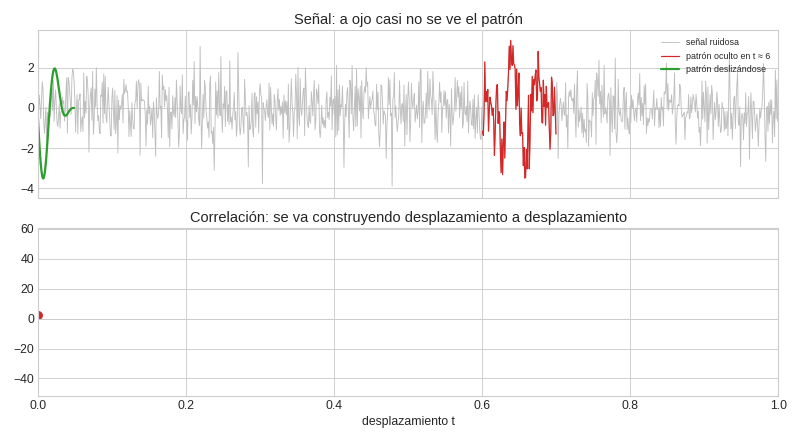

In [39]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

# --- por si todavía no están definidas las variables ---
if 'senal' not in globals():
    rng = np.random.default_rng(0)
    t = np.linspace(0, 10, 1000)
    x = np.linspace(0, 1, 100)
    patron = np.hanning(100) * np.sin(2*np.pi*3*x)
    senal = rng.normal(0, 1.0, t.size)
    senal[600:700] += 3*patron

N, M = senal.size, patron.size
corr = np.correlate(senal, patron, mode='same')   # se calcula UNA sola vez

FRAMES = 180
idx = np.linspace(0, N-1, FRAMES).astype(int)     # muestreo de posiciones
esc  = 0.9*np.abs(senal).max()/np.abs(patron).max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True)

ax1.plot(t, senal, color='0.75', lw=0.8, label='señal ruidosa')
ax1.plot(t[600:700], senal[600:700], color='tab:red', lw=1.1, label='patrón oculto en t ≈ 6')
mov, = ax1.plot([], [], color='tab:green', lw=2, label='patrón deslizándose')
vl1  = ax1.axvline(t[0], color='tab:green', ls=':', lw=1)
ax1.set_ylim(1.15*senal.min(), 1.15*senal.max())
ax1.set_title("Señal: a ojo casi no se ve el patrón"); ax1.legend(fontsize=8, loc='upper right')

linea, = ax2.plot([], [], color='tab:blue', lw=2)
punto, = ax2.plot([], [], 'o', color='tab:red', ms=7)
ax2.set_ylim(1.15*corr.min(), 1.15*corr.max()); ax2.set_xlim(t[0], t[-1])
ax2.axhline(0, color='0.8', lw=0.8)
ax2.set_title("Correlación: se va construyendo desplazamiento a desplazamiento")
ax2.set_xlabel("desplazamiento t")
plt.tight_layout()

def update(f):
    k = idx[f]
    a  = k - M//2
    lo, hi = max(a, 0), min(a + M, N)
    mov.set_data(t[lo:hi], patron[lo-a:hi-a]*esc)
    vl1.set_xdata([t[k], t[k]])
    linea.set_data(t[:k+1], corr[:k+1])
    punto.set_data([t[k]], [corr[k]])
    return mov, vl1, linea, punto

ani = FuncAnimation(fig, update, frames=FRAMES, interval=50, blit=True)
ani.save('correlacion.gif', writer=PillowWriter(fps=25), dpi=80)
plt.close(fig)

display(Image('correlacion.gif'))


---
## Senos y Cosenos como "Vectores Canónicos" (La Base Ortogonal)

En $\mathbb{R}^3$, la base canónica es $\{e_1, e_2, e_3\}$.
¿Qué tiene de especial esa base?
$$e_1 \cdot e_2 = 0, \quad e_1 \cdot e_3 = 0, \quad e_2 \cdot e_3 = 0$$
$$e_1 \cdot e_1 = 1, \quad e_2 \cdot e_2 = 1, \quad e_3 \cdot e_3 = 1$$
Son **perpendiculares entre sí** (ortogonales) y de longitud 1 (ortonormales).

En el espacio de funciones periódicas en $[-\pi, \pi]$, Fourier propuso usar como base:
$$\mathcal{B} = \{ 1, \cos(x), \sin(x), \cos(2x), \sin(2x), \dots, \cos(nx), \sin(nx), \dots \}$$

### **Demostración**: ¿Son realmente ortogonales? ("Da 0 si son distintas, da $\pi$ si son iguales")

Calculemos el producto interno entre dos funciones de esta base en el intervalo $[-\pi, \pi]$:

#### **Caso 1:** Coseno con Coseno de distinta frecuencia ($n \neq m$)
Usando la identidad trigonométrica $\cos(A)\cos(B) = \frac{1}{2}[\cos(A-B) + \cos(A+B)]$:
$$\langle \cos(nx), \cos(mx) \rangle = \int_{-\pi}^\pi \cos(nx) \cos(mx) dx = \frac{1}{2} \int_{-\pi}^\pi [\cos((n-m)x) + \cos((n+m)x)] dx$$
Como $n \neq m$, ambas son ondas cosenoidales completas en el intervalo $[-\pi, \pi]$. La integral de un coseno completo es su área positiva cancelándose exactamente con su área negativa:
$$= \frac{1}{2} \left[ \frac{\sin((n-m)x)}{n-m} + \frac{\sin((n+m)x)}{n+m} \right]_{-\pi}^\pi = 0$$

#### **Caso 2:** Coseno con Coseno de la misma frecuencia ($n = m$)
$$\langle \cos(nx), \cos(nx) \rangle = \int_{-\pi}^\pi \cos^2(nx) dx = \int_{-\pi}^\pi \frac{1 + \cos(2nx)}{2} dx = \left[ \frac{x}{2} + \frac{\sin(2nx)}{4n} \right]_{-\pi}^\pi = \frac{\pi - (-\pi)}{2} = \pi$$

#### **Caso 3:** Coseno con Seno (cruzados)
Para cualquier $n$ y $m$:
$$\langle \cos(nx), \sin(mx) \rangle = \int_{-\pi}^\pi \underbrace{\cos(nx)}_{\text{par}} \cdot \underbrace{\sin(mx)}_{\text{impar}} dx = \int_{-\pi}^\pi \text{función impar } dx = 0$$

#### ** Caso 4 y 5:** Seno con Seno (distinta y misma frecuencia) Pueden probarlo ustedes si quieren, es analogo por la identidad $ trigonométrica
$$\int_{-\pi}^\pi \cos(nx) \cos(mx) dx = \begin{cases} 0 & \text{si } n \neq m \\ \pi & \text{si } n = m \end{cases}$$
$$\int_{-\pi}^\pi \sin(nx) \sin(mx) dx = \begin{cases} 0 & \text{si } n \neq m \\ \pi & \text{si } n = m \end{cases}$$
$$\int_{-\pi}^\pi \cos(nx) \sin(mx) dx = 0 \quad \text{siempre}$$

> 💡 **¡Son exactamente como los vectores canónicos $e_1, e_2, e_3$!**
> Cada frecuencia $n$ apunta en una dimensión completamente perpendicular a todas las demás frecuencias.

> Entonces la base:
$$\mathcal{B} = \{ 1, \cos(x), \sin(x), \cos(2x), \sin(2x), \dots, \cos(nx), \sin(nx), \dots \}$$
Es **Ortonormal** en el espacio de funciones.


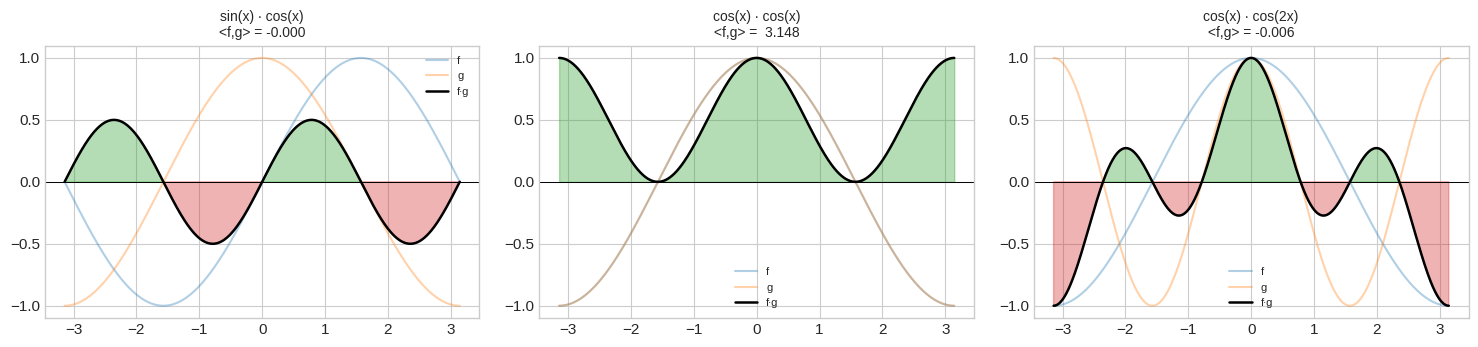

In [40]:
x = np.linspace(-np.pi, np.pi, 1000)
dx = x[1] - x[0]

pares = [(np.sin(x),      np.cos(x),      "sin(x) · cos(x)"),
         (np.cos(x),      np.cos(x),      "cos(x) · cos(x)"),
         (np.cos(x),      np.cos(2*x),    "cos(x) · cos(2x)")]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, (f, g, nombre) in zip(axes, pares):
    prod = f * g
    ax.plot(x, f, alpha=0.35, label='f')
    ax.plot(x, g, alpha=0.35, label='g')
    ax.plot(x, prod, color='k', lw=1.8, label='f·g')
    ax.fill_between(x, prod, where=prod >= 0, color='tab:green', alpha=0.35)
    ax.fill_between(x, prod, where=prod <  0, color='tab:red',   alpha=0.35)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_title(f"{nombre}\n<f,g> = {np.sum(prod)*dx: .3f}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

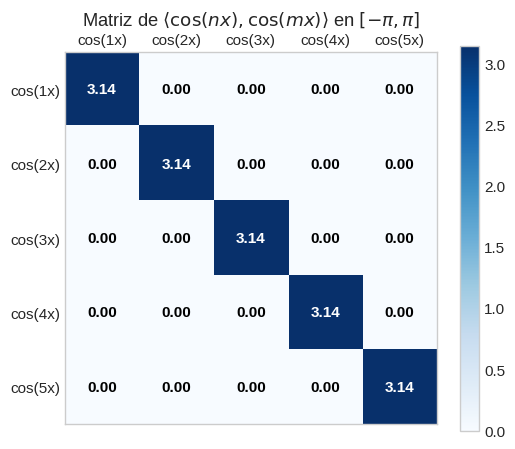

In [41]:
# Demostracion numerica: Matriz de Productos Internos entre Frecuencias
N_frecuencias = 5
matriz_cosenos = np.zeros((N_frecuencias, N_frecuencias))
x = np.linspace(-np.pi, np.pi, 2000)
dx = x[1] - x[0]

for n in range(1, N_frecuencias + 1):
    for m in range(1, N_frecuencias + 1):
        cos_n = np.cos(n * x)
        cos_m = np.cos(m * x)
        # Producto interno: integral aproximada
        matriz_cosenos[n-1, m-1] = np.sum(cos_n * cos_m) * dx

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(matriz_cosenos, cmap='Blues')
fig.colorbar(cax)
ax.set_xticks(range(N_frecuencias))
ax.set_yticks(range(N_frecuencias))
ax.set_xticklabels([f"cos({i}x)" for i in range(1, N_frecuencias + 1)])
ax.set_yticklabels([f"cos({i}x)" for i in range(1, N_frecuencias + 1)])
ax.set_title(r"Matriz de $\langle \cos(nx), \cos(mx) \rangle$ en $[-\pi, \pi]$", pad=20)
ax.grid(False)
for i in range(N_frecuencias):
    for j in range(N_frecuencias):
        val = matriz_cosenos[i, j]
        ax.text(j, i, f"{val:.2f}" if abs(val) > 0.05 else "0.00",
                ha="center", va="center", color="black" if val < 2 else "white", fontweight='bold')

plt.show()


##¿Cómo se consiguen los coeficientes $a_n$ y $b_n$?

Hemos visto que cualquier señal periódica se puede escribir como:

$$ f(t) = a_0 + \sum_{n=1}^{\infty} \left[ a_n \cos(n\omega_0 t) + b_n \sin(n\omega_0 t) \right] \quad (1)$$

porque $\mathcal{B}$ es base **Ortonormal**

Pero... **¿cómo obtenemos esos números $a_n$ y $b_n$ a partir de una señal concreta?** Periodo $[0,T]$.

En los libros de texto, te presentan de golpe estas dos fórmulas:
- Para $a_0$:  
  $$ a_0= \frac{1}{T} \int_0^T f(t) \, dt $$

- Para $a_n$ (con $n \ge 1$):  
  $$ a_n =  \frac{2}{T} \int_0^T f(t) \cos(n\omega t) \, dt $$

- Para $b_n$:  
  $$ b_n = \frac{2}{T} \int_0^T f(t) \sin(n\omega t) \, dt $$

### ¿De dónde salen? ¡De una proyección ortogonal elemental de Álgebra Lineal!

Recordá la fórmula de Álgebra Lineal para proyectar un vector $\vec{v}$ sobre una base ortogonal $\{\vec{e}_1, \vec{e}_2, \dots\}$:

$$c_k = \frac{\langle \vec{v}, \vec{e}_k \rangle}{\langle \vec{e}_k, \vec{e}_k \rangle} = \frac{\langle f,g_k\rangle}{\|g_k\|^2}$$
y como usamos $g_k \in \mathcal{B}$ que son **Ortonormales** entonces, $\|g_k\|^2 =1$.

Si la base está formada por las funciones $\cos(n\omega_0 t)$ y $\sin(n\omega_0 t)$, el coeficiente $a_{\textbf{k}}$ (para un ***n*** en especifico = k) se obtiene haciendo el **producto interno** entre $f(t)$ y $\cos(\textbf{k}\omega_0 t)$.

$$ a_k = \langle f(t), \cos(k\omega_0 t) \rangle  $$

Desarrolamos el producto interno y  remplazamos $f(t)$ por su expreción (1).

$$\int_{0}^T f(t) \cos(k \omega_0 t) dt = \int_{0}^T \left( \frac{a_0}{2} + \sum_{n=1}^\infty [a_n \cos(n\omega_0t) + b_n \sin(n\omega_0t)] \right) \cos(k\omega_0t) dt$$

Distribuimos $\cos(k\omega_0t)$ y la integral, término a término:

$$\int_{0}^T \frac{a_0}{2} \cos(k\omega_0t) dt +  \sum_{n=1}^\infty\int_{0}^T a_n \cos(n\omega_0t)\cos(k\omega_0t) dt+  \sum_{n=1}^\infty \int_{0}^T b_n \sin(n\omega_0t) \cos(k\omega_0t) dt$$

- $\int \frac{a_0}{2} \cos(k\omega_0t) dt = 0$ (porque la constante 1 es ortogonal a $\cos(k\omega_0t)$).
- Todos los $\int b_n \sin(n\omega_0t) \cos(k\omega_0t) dt = 0$ (porque senos y cosenos son ortogonales entre sí).
- En la sumatoria de $\int a_n \cos(n\omega_0t) \cos(k\omega_0t) dt$, **todos los términos dan $0$ excepto cuando $n = k$**.

Entonces:

$$\int_{0}^T f(t) \cos(k\omega_0t) dt = a_k \int_{0}^T \cos^2(k\omega_0t) dt$$

Y como demostramos hace un rato, $\int_{0}^T \cos^2(k\omega_0t) dt = T/2$. Por lo tanto:
$$\int_{0}^T f(t) \cos(k\omega_0t) dt = a_k \cdot T/2$$

Despejás $a_k$:
$$\mathbf{a_k = \frac{2}{T} \int_{0}^T f(t) \cos(k\omega_0t)} dt$$

Y si hacés el producto interno con $\sin(k\omega_0t)$, sobrevive únicamente el término $b_k$:
$$\mathbf{b_k = \frac{2}{T} \int_{0}^T f(t) \sin(k\omega_0t) dt}$$


> Entonces, los coeficientes $\textbf{a_k}$ y $\textbf{b_k}$ son simplemente las **coordenadas** de la función $f(t)$ proyectado sobre los ejes canónicos del espacio de funciones $\cos(k\omega_0t)$ y $\sin(k\omega_0t)$.






#Euler: de $(a_n, b_n)$ a un único $c_n$

Tener dos juegos de coeficientes ($a_n$ para cosenos y $b_n$ para senos) es engorroso.
Aquí entra la identidad de Euler:
$$\mathbf{e^{i\theta} = \cos(\theta) + i\sin(\theta)}$$

### ¿Por qué esto simplifica todo?
En vez de dos bases trigonométricas reales separadas, usamos una **única base exponencial compleja**:
$$\mathcal{B}_{compleja} = \{ \dots, e^{-i2x}, e^{-ix}, 1, e^{ix}, e^{i2x}, \dots \}$$

Cualquier función se escribe como una única serie:
$$\mathbf{f(x) = \sum_{n=-\infty}^\infty c_n e^{inx}}$$

¿Y cómo calculamos la coordenada compleja $c_n$?
Nuevamente con el **producto interno** (en espacios complejos usamos el conjugado $\langle f, g \rangle = \int f(x) \overline{g(x)} dx$):
$$c_n = \frac{1}{T} \int_{0}^T f(t) e^{-i\frac{2 \pi n}{T}t} dt$$

### ¿Qué representa geométricamente el número complejo $c_n$?
Cada $c_n$ es un vector en el plano complejo:
- **Su magnitud $|c_n|$:** es la **amplitud** (cuánta energía o peso tiene esa frecuencia).
- **Su ángulo $\angle c_n$:** es la **fase** (cuánto está desplazada horizontalmente esa onda).

$$c_n = |c_n| e^{i \phi_n} = \underbrace{|c_n|}_{\text{Amplitud}} \angle \underbrace{\phi_n}_{\text{Fase}}$$

# De la serie a la transformada: el salto de lo periódico a lo aperiódico

## El punto de partida

Hasta ahora trabajamos con señales **periódicas**, que se repiten cada \(T\) segundos. Su espectro es **discreto**, con $f_0 = 1/T$.

$$
f(t)=\sum_{n=-\infty}^{\infty}c_n\,e^{i2\pi n f_0t},
\qquad
c_n=\frac{1}{T}\int_0^T f(t)\,e^{-i2\pi n f_0t}\,dt
$$

## El problema

¿Y si la señal **no se repite**? Como un solo pulso, un golpe de tambor, un audio de dos segundos.

Ya no tenemos un período \(T\) ni frecuencias discretas.

## La idea

Imaginamos que la señal se repite, pero cada vez con un período más grande:

$$
T\longrightarrow\infty
$$

Como

$$
f_0=\frac{1}{T}\longrightarrow0,
$$

las frecuencias \(nf_0\) quedan cada vez más juntas, hasta formar un **continuo de frecuencias**.

Por eso pasamos de:

| Serie de Fourier               | Transformada                |
| ------------------------------ | --------------------------- |
| Frecuencias discretas \(nf_0\) | Todas las frecuencias \(f\) |
| Coeficientes \(c_n\)           | Función \(F(f)\)            |
| Suma \(\sum_n\)                | Integral \(\int df\)        |

## Definición

La **transformada de Fourier** es:

$$
\boxed{
F(f)=\int_{-\infty}^{\infty}
f(t)\,e^{-i2\pi ft}\,dt
}
$$

Ahora \(F(f)\) nos dice **cuánto hay de cada frecuencia \(f\)** en la señal.

Y para volver al dominio temporal:

$$
\boxed{
f(t)=\int_{-\infty}^{\infty}
F(f)\,e^{i2\pi ft}\,df
}
$$

En resumen:

$$
\boxed{
\text{Serie: suma de frecuencias discretas}
\quad\longrightarrow\quad
\text{Transformada: integral de frecuencias continuas}
}
$$



# 8. La DFT: la versión de la computadora

En una computadora una señal no tiene infinitos puntos continuos: tiene $N$ muestras.

$$\vec{x} = [x_0, x_1, \dots, x_{N-1}]^T$$

Y entonces:
- la integral **se convierte de nuevo en una suma finita**
- las frecuencias posibles **son finitas**: sólo $N$ de ellas,
- todo se puede escribir como **una multiplicación matriz por vector**.

$$X_k = \sum_{n=0}^{N-1} x_n\, e^{-i\frac{2\pi}{N}kn}
\qquad\Longleftrightarrow\qquad
\boxed{\;\vec{X} = W\vec{x}\;}$$

donde $W$ es la **matriz de Fourier**, $W_{kn} = e^{-i\frac{2\pi}{N}kn}$:

$$\begin{bmatrix} X_0 \\ X_1 \\ \vdots \\ X_{N-1}\end{bmatrix} =
\begin{bmatrix}
1 & 1 & 1 & \dots & 1\\
1 & W_N & W_N^2 & \dots & W_N^{N-1}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & W_N^{N-1} & W_N^{2(N-1)} & \dots & W_N^{(N-1)^2}
\end{bmatrix}
\begin{bmatrix} x_0 \\ x_1 \\ \vdots \\ x_{N-1}\end{bmatrix},
\qquad W_N = e^{-i\frac{2\pi}{N}}$$

**Cada fila $k$ de $W$ es una onda discreta** de frecuencia $k$ (parte real: coseno; parte imaginaria: $-$seno).
Multiplicar $W\vec{x}$ es hacer **un producto interno de la señal contra cada onda**. Nada más.

### ¿Qué propiedades tiene la matriz $W$?
1. Sus columnas son **ortogonales** entre sí en $\mathbb{C}^N$.
2. Por lo tanto, su inversa es simplemente su **traspuesta conjugada** (dividida por $N$):
   $$\mathbf{W^{-1} = \frac{1}{N} W^H}$$
3. Reconstrucción (IDFT):
   $$\vec{x} = \frac{1}{N} W^H \vec{X}$$

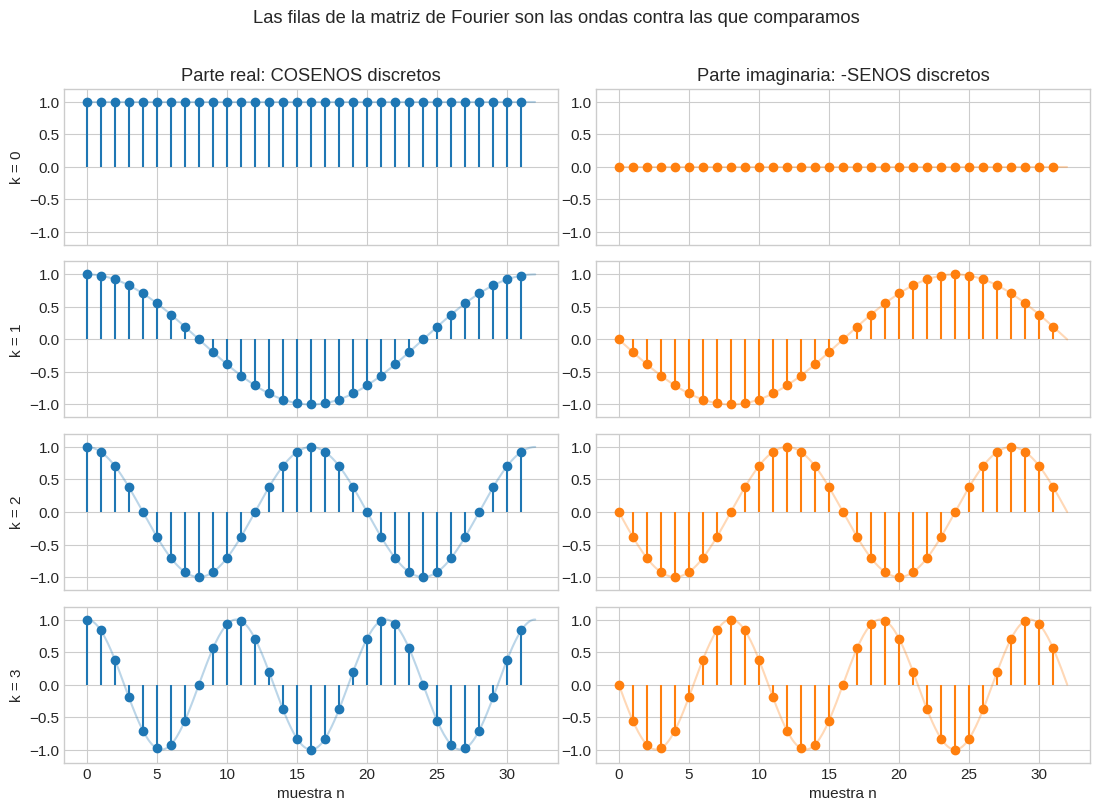

In [43]:
# Cantidad de muestras
N = 32

# Índices de las muestras
n = np.arange(N)

# Matriz de Fourier discreta
# W[k,n] = exp(-i 2π k n / N)
# Cada fila k representa una onda de frecuencia k.
W = np.exp(-2j * np.pi * np.outer(np.arange(N), n) / N)

# Las filas de W son ondas discretas de frecuencia creciente
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex=True)
for k_idx in range(4):
    axes[k_idx, 0].stem(n, np.real(W[k_idx, :]), basefmt=" ")
    axes[k_idx, 0].set_ylabel(f"k = {k_idx}")
    axes[k_idx, 1].stem(n, np.imag(W[k_idx, :]), basefmt=" ",
                        linefmt='tab:orange', markerfmt='o')
    # onda continua de fondo, para ver que los puntos son muestras de un coseno/seno
    tt = np.linspace(0, N, 300)
    axes[k_idx, 0].plot(tt, np.cos(2*np.pi*k_idx*tt/N), color='tab:blue', alpha=0.3)
    axes[k_idx, 1].plot(tt, -np.sin(2*np.pi*k_idx*tt/N), color='tab:orange', alpha=0.3)
    axes[k_idx, 0].set_ylim(-1.2, 1.2); axes[k_idx, 1].set_ylim(-1.2, 1.2)
axes[0, 0].set_title("Parte real: COSENOS discretos")
axes[0, 1].set_title("Parte imaginaria: -SENOS discretos")
axes[-1, 0].set_xlabel("muestra n"); axes[-1, 1].set_xlabel("muestra n")
plt.suptitle("Las filas de la matriz de Fourier son las ondas contra las que comparamos", y=1.01)
plt.tight_layout(); plt.show()

##La DFT escrita como correlación

Escribámosla con el loop explícito, para ver que **es exactamente el producto interno, hecho contra cada onda**:

```python
for frecuencia in range(N):
    energia = 0
    for t in range(N):
        onda = cos(w*t) - i*sin(w*t)     # <-- el signo menos: comparar es correlacionar
        energia += señal[t] * onda        # <-- multiplicar punto a punto y sumar
    X[frecuencia] = energia
```

Y del número complejo `energia` sacamos las dos cosas que nos interesan:

$$|X_k| = \text{cuánta de esa frecuencia hay} \qquad \angle X_k = \text{con qué desfase entra}$$

## La DFT escrita como correlación

Escribamos la DFT con los `for` explícitos para ver que es exactamente un **producto interno entre la señal y cada onda de Fourier**:

$$
X_k =
\sum_{t=0}^{N-1}
x_t\,e^{-i2\pi kt/N}
$$



# 1. Ejercicio

Programá la transformada de Fourier discreta desde cero, usando la fórmula anterior y **sin utilizar `np.fft`**.

El resultado \(X_k\) es un número complejo. De él podemos obtener:

$$
|X_k| = \text{cuánto hay de la frecuencia } k
$$

$$
\angle X_k = \text{fase de la frecuencia } k
$$


In [54]:
def mi_dft(x):

    N = len(x)
    X = np.zeros(N, dtype=complex)

    for k in range(N):

        suma = 0

        for t in range(N):

            # Completar:
            angulo = 2*np.pi*k*t/N
            suma += x[t]*(np.cos(angulo)-1j*np.sin(angulo))
        X[k] = suma

    return X

test 1: esto les da casi 0?
4.1318842793814754e-11
test 2: picos en 5,40 y 120?


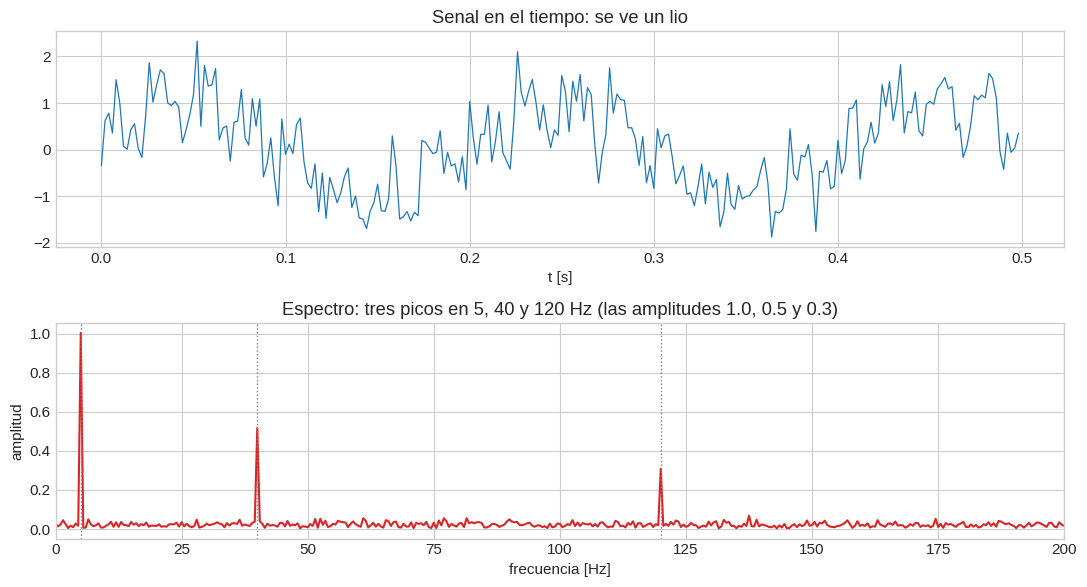

In [58]:
# Señal con tres tonos escondidos + ruido: la DFT los saca a la luz
fs = 500.0                       # Hz
T  = 2.0                         # segundos
t  = np.arange(0, T, 1/fs)
N  = len(t)
señal = (1.0*np.sin(2*np.pi*  5*t) +
         0.5*np.sin(2*np.pi* 40*t) +
         0.3*np.cos(2*np.pi*120*t) +
         0.4*rng.normal(0, 1, N))


print("test 1: esto les da casi 0?")
X_mia = mi_dft(señal)
X_numpy = np.fft.fft(señal)
print(np.max(np.abs(X_mia - X_numpy)))

print("test 2: picos en 5, 40 y 120?")
X     = fft(señal)
freqs = fftfreq(N, 1/fs)
mitad = freqs >= 0                       # nos quedamos con la mitad util

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(t[:250], señal[:250], lw=0.9)
ax1.set_title("Senal en el tiempo: se ve un lio"); ax1.set_xlabel("t [s]")

ax2.plot(freqs[mitad], 2*np.abs(X[mitad])/N, color='tab:red')
ax2.set_xlim(0, 200); ax2.set_xlabel("frecuencia [Hz]"); ax2.set_ylabel("amplitud")
ax2.set_title("Espectro: tres picos en 5, 40 y 120 Hz (las amplitudes 1.0, 0.5 y 0.3)")
for f0 in (5, 40, 120):
    ax2.axvline(f0, color='gray', ls=':', lw=1)
plt.tight_layout(); plt.show()


# Fourier 2D: imágenes

Todo lo anterior se transplanta sin cambios. Lo único nuevo es que ahora hay **dos índices**.

$$F(u, v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x,y)\, e^{-i2\pi\left(\frac{ux}{M} + \frac{vy}{N}\right)}$$

### Las funciones base ahora son **ondas planas**
Una base 2D es una onda que oscila en una **dirección** del plano. Tiene:
- una frecuencia horizontal $u$,
- una frecuencia vertical $v$,
- y por lo tanto una **orientación** $\theta = \arctan(v/u)$ y una **frecuencia total** $\sqrt{u^2+v^2}$.

Visualmente: **franjas** (rayas) más o menos juntas, con una inclinación.
Una imagen es una **superposición de rayas**.

### La DFT 2D es **separable**
$$F = W\, f\, W^T$$
Aplicás la matriz de Fourier a las **filas** y después a las **columnas**. Por eso es barata.

### Cómo se lee un espectro (con `fftshift`, el cero al centro)
| Dónde | Qué es en la imagen |
| :-- | :-- |
| **Centro** (bajas frecuencias) | fondos, zonas lisas, iluminación general, formas grandes |
| **Periferia** (altas frecuencias) | bordes, texturas finas, detalle, ruido |
| **Dirección** de un pico | orientación de las rayas: un pico *horizontal* ⇒ rayas *verticales* |
| **Píxel central** $F(0,0)$ | la suma de todos los píxeles = el brillo promedio |

In [ ]:
# Las bases 2D: ondas planas con distintas frecuencias horizontal y vertical
def base_2d(size, u, v):
    M, N = size
    y, x = np.mgrid[0:M, 0:N]
    return np.cos(2*np.pi*(u*x/N + v*y/M))

U, V = 4, 4
fig, axes = plt.subplots(V, U, figsize=(9, 9))
for v in range(V):
    for u in range(U):
        axes[v, u].imshow(base_2d((32, 32), u, v), cmap='gray', vmin=-1, vmax=1)
        axes[v, u].set_title(f"u={u}, v={v}", fontsize=8)
        axes[v, u].axis('off')
plt.suptitle("Base de Fourier 2D: rayas con distinta separacion y orientacion", y=0.99)
plt.tight_layout(); plt.show()

print("u = frecuencia horizontal (rayas verticales)")
print("v = frecuencia vertical   (rayas horizontales)")
print("u y v juntos -> rayas inclinadas")

In [ ]:
# Funciones auxiliares que vamos a reutilizar
def espectro_log(F):
    # log(1 + |F|) centrado: sin el log solo se ve un punto en el centro
    return np.log1p(np.abs(fftshift(F)))

def mostrar_dft(imagen, titulo=""):
    F = fft2(imagen)
    recon = np.real(ifft2(F))
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(imagen, cmap='gray');            axes[0].set_title("Imagen")
    axes[1].imshow(espectro_log(F), cmap='gray');   axes[1].set_title("log(1+|F|)  MAGNITUD")
    axes[2].imshow(np.angle(fftshift(F)), cmap='gray'); axes[2].set_title("FASE")
    axes[3].imshow(recon, cmap='gray');             axes[3].set_title("IDFT (vuelta)")
    for ax in axes: ax.axis('off')
    fig.suptitle(titulo, fontsize=13)
    plt.tight_layout(); plt.show()
    return F

D = 150
cuadrado = np.zeros((D, D)); rr, cc = rectangle(start=(65, 65), extent=(20, 20)); cuadrado[rr, cc] = 255
_ = mostrar_dft(cuadrado, "Cuadrado central")

In [ ]:
# Galeria: como se ve el espectro de formas geometricas simples
figuras = {}

img = np.zeros((D, D)); rr, cc = rectangle(start=(20, 40), extent=(20, 20)); img[rr, cc] = 255
figuras["Cuadrado trasladado"] = img

img = np.zeros((D, D)); rr, cc = rectangle(start=(30, 30), extent=(40, 20)); img[rr, cc] = 255
figuras["Rectangulo (angosto en x)"] = img

img = np.zeros((D, D)); rr, cc = line(20, 50, 120, 50); img[rr, cc] = 255
figuras["Linea vertical"] = img

img = np.zeros((D, D)); rr, cc = line(20, 20, 120, 120); img[rr, cc] = 255
figuras["Linea a 45 grados"] = img

img = np.zeros((D, D)); img[:, ::15] = 255      # peine perfectamente periodico
figuras["Rayas verticales periodicas"] = img

img = base_2d((D, D), 12, 5)
figuras["Onda plana pura (u=12, v=5)"] = img

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for j, (nombre, im) in enumerate(figuras.items()):
    axes[0, j].imshow(im, cmap='gray'); axes[0, j].set_title(nombre, fontsize=9); axes[0, j].axis('off')
    axes[1, j].imshow(espectro_log(fft2(im)), cmap='gray'); axes[1, j].axis('off')
plt.suptitle("Arriba: la imagen.   Abajo: la MAGNITUD de su espectro (centrada con fftshift + log)",
             y=1.01, fontsize=12)
plt.tight_layout(); plt.show()